<a href="https://colab.research.google.com/github/jesteenaec2529-collab/s2codebase/blob/main/Experiment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Experiment No 4**

Evaluating divergence and curl of a vector field and visualize

#**Case**: Find the divergence and curl of a vector field
$\vec{F}=xy\hat{i}+yz\hat{j}+zx\hat{k}$ and plot the vector fields.

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy.vector import CoordSys3D

#N = C

In [2]:
#Define the coordinate system

N=sp.vector.CoordSys3D('N')
#define the vector field (example : F = x*y*i+y*z*j+z*)
F = (N.x*N.y)*N.i+(N.y*N.z)*N.j+(N.z*N.x)*N.k

F

N.x*N.y*N.i + N.y*N.z*N.j + N.x*N.z*N.k

In [3]:
#compute the divergence
divergence_F =sp.vector.divergence(F)
divergence_F

N.x + N.y + N.z

In [4]:
#compute the CURL
curl_F =sp.vector.curl(F)
curl_F

(-N.y)*N.i + (-N.z)*N.j + (-N.x)*N.k

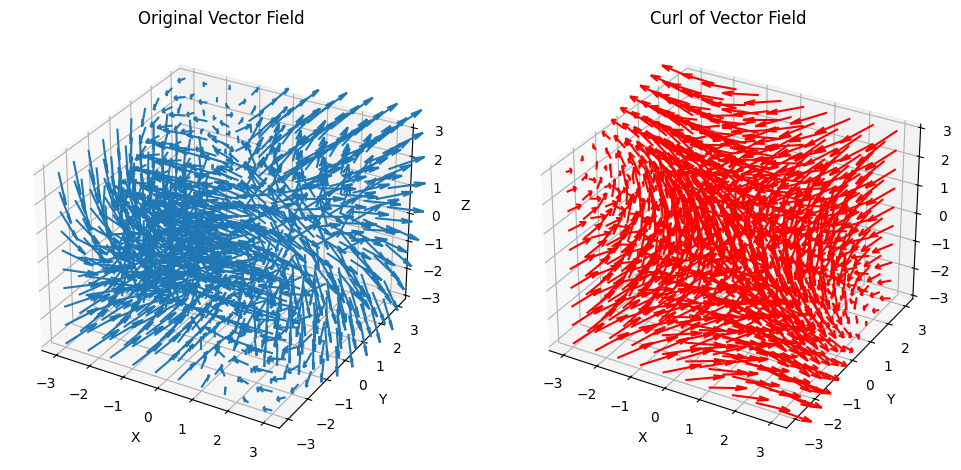

In [5]:
from sympy.printing.pretty.pretty_symbology import U
# Define the grid
x_vals = np.linspace(-3, 3, 10)
y_vals = np.linspace(-3, 3, 10)
z_vals = np.linspace(-3, 3, 10)
X,Y,Z,=np.meshgrid(x_vals,y_vals,z_vals)


# intialize arrays to store the vector field components
U_vals = np.zeros_like(X)
V_vals = np.zeros_like(Y)
W_vals = np.zeros_like(Z)

## intialize arrays to store the curl components
curl_U = np.zeros_like(X)
curl_V= np.zeros_like(Y)
curl_W = np.zeros_like(Z)

#evaluate the vector field and curl at each grid point

for i in range(X.shape[0]):
  for j in range(X.shape[1]):
    for k in range(X.shape[2]):
      point = {N.x :X[i,j,k],N.y:Y[i,j,k],N.z:Z[i,j,k]}
      F_evaluted=F.subs(point)
      U_vals[i,j,k] = float(F_evaluted.dot(N.i))
      V_vals[i,j,k] = float(F_evaluted.dot(N.j))
      W_vals[i,j,k] = float(F_evaluted.dot(N.k))
      curl_evaluted = curl_F.subs(point)
      curl_U[i,j,k] = float(curl_evaluted.dot(N.i))
      curl_V[i,j,k] = float(curl_evaluted.dot(N.j))
      curl_W[i,j,k] = float(curl_evaluted.dot(N.k))

#plot the original vector field
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(121, projection='3d')
ax.quiver(X,Y,Z,U_vals,V_vals,W_vals,length=1,normalize=True)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Original Vector Field')

#plot the curl
ax2= fig.add_subplot(122, projection='3d')
ax2.quiver(X,Y,Z,curl_U,curl_V,curl_W,length=1,normalize=True,color='r')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Curl of Vector Field')

plt.show()





### Application Problem :Vorticity and Fluid Flow in a Pipe

### Problem Statement

Consider a cylinderical pipe through which fluid is flowing . The velocity field of the fluid inside the pipe is described by a three-dimensional vector field  $ V(x,y,z)=(-y,x,0)$

(i)Determine the divergence $\nabla.V$, which measures the net rate of fluid flow out of a point, at any point $(x,y,z)$ in the pipe.

(ii)Determine the curl $\nabla\times.V$, which measures the rotation or swirling strength of the fluid flow around a point, at any point $(x,y,z)$ in the pipe.



In [6]:
#Define the coordinate system

N=sp.vector.CoordSys3D('N')
#define the vector field (example : F = x*y*i+y*z*j+z*)
V = (-N.y)*N.i+(N.x)*N.j+(0)*N.k

V

(-N.y)*N.i + N.x*N.j

In [7]:
#compute the divergence
divergence_V =sp.vector.divergence(V)
divergence_V

0

In [8]:
#compute the CURL
curl_V =sp.vector.curl(V)
curl_V


2*N.k

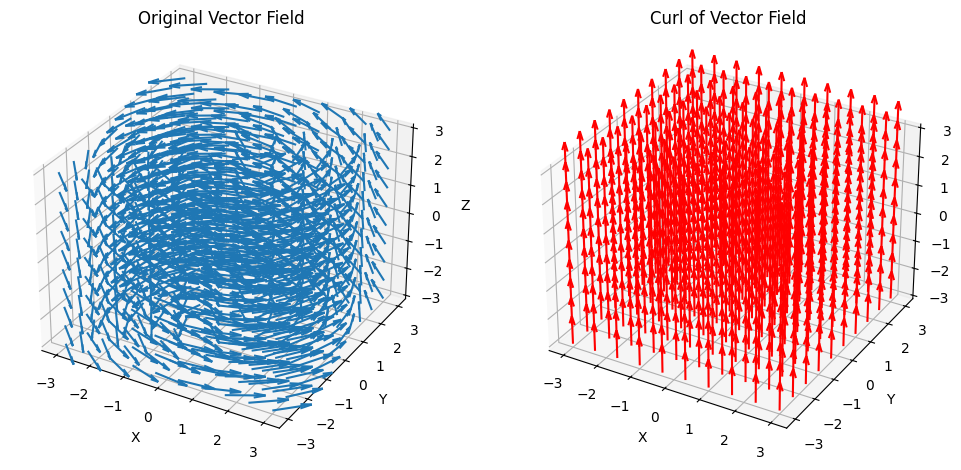

In [9]:
from sympy.printing.pretty.pretty_symbology import U
# Define the grid
x_vals = np.linspace(-3, 3, 10)
y_vals = np.linspace(-3, 3, 10)
z_vals = np.linspace(-3, 3, 10)
X,Y,Z,=np.meshgrid(x_vals,y_vals,z_vals)


# intialize arrays to store the vector field components
U_vals = np.zeros_like(X)
V_vals = np.zeros_like(Y)
W_vals = np.zeros_like(Z)

## intialize arrays to store the curl components
curl_U_comp = np.zeros_like(X)
curl_V_comp = np.zeros_like(Y)
curl_W_comp = np.zeros_like(Z)

#evaluate the vector field and curl at each grid point

for i in range(X.shape[0]):
  for j in range(X.shape[1]):
    for k in range(X.shape[2]):
      point = {N.x :X[i,j,k],N.y:Y[i,j,k],N.z:Z[i,j,k]}
      V_evaluted=V.subs(point)
      U_vals[i,j,k] = float(V_evaluted.dot(N.i))
      V_vals[i,j,k] = float(V_evaluted.dot(N.j))
      W_vals[i,j,k] = float(V_evaluted.dot(N.k))
      curl_evaluted = curl_V.subs(point)
      curl_U_comp[i,j,k] = float(curl_evaluted.dot(N.i))
      curl_V_comp[i,j,k] = float(curl_evaluted.dot(N.j))
      curl_W_comp[i,j,k] = float(curl_evaluted.dot(N.k))

#plot the original vector field
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(121, projection='3d')
ax.quiver(X,Y,Z,U_vals,V_vals,W_vals,length=1,normalize=True)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Original Vector Field')

#plot the curl
ax2= fig.add_subplot(122, projection='3d')
ax2.quiver(X,Y,Z,curl_U_comp,curl_V_comp,curl_W_comp,length=1,normalize=True,color='r')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Curl of Vector Field')

plt.show()

